In [86]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from cycler import cycler

main_colours = plt.cm.rainbow(np.linspace(0, 1, 5))

custom_params = {
    "xtick.direction": "in",
    "ytick.direction": "in",
    "lines.markeredgecolor": "#131313",
    "lines.markeredgewidth": 1.25,
    "figure.dpi": 200,
    "text.usetex": True,
    "font.family": "serif",
    "axes.prop_cycle": cycler(color=main_colours),
}

sns.set_theme(context="talk", style="ticks", rc=custom_params)

In [87]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Physical parameters: your colloid scale
# ============================================================

a = 1e-6  # particle radius, m
rho_f = 1000  # fluid density, kg/m^3
deltarho = 50  # particle-fluid density diff, kg/m^3
rho_p = rho_f + deltarho

V = 4 / 3 * np.pi * a**3
g = 0
kBT = 4.19e-21
eta = 0.001


m = rho_p * V
gamma = 6 * np.pi * eta * a

tau = m / gamma
vT2 = kBT / m
vT = np.sqrt(vT2)
D = kBT / gamma


Fg = deltarho * V * g
v_sed = Fg / gamma


# ============================================================
# Simulation parameters
# ============================================================

tmax = 1000 * tau

dt_list = tau * np.array([1.5, 1.0, 0.1, 0.01])

# Number of trajectories
ntraj = 1000

rng = np.random.default_rng(1234)


# ============================================================
# Exact results
# ============================================================


def exact_velocity_variance_from_zero(t):

    return vT2 * (1 - np.exp(-2 * t / tau))


def exact_msd_equilibrium_velocity(t):
    return 2 * D * (t - tau * (1 - np.exp(-t / tau)))


# ============================================================
# Euler-Maruyama
# ============================================================


def simulate_underdamped_euler(dt):

    nsteps = int(np.round(tmax / dt))
    t = np.arange(nsteps + 1) * dt

    x = np.zeros((ntraj, nsteps + 1))
    v = np.zeros((ntraj, nsteps + 1))

    v[:, 0] = rng.normal(0.0, vT, size=ntraj)

    drift_velocity = 0.0

    noise_prefactor = np.sqrt(2 * vT2 * dt / tau)

    for n in range(nsteps):
        xi = rng.normal(0.0, 1.0, size=ntraj)

        v[:, n + 1] = (
            v[:, n] - (dt / tau) * (v[:, n] - drift_velocity) + noise_prefactor * xi
        )

        x[:, n + 1] = x[:, n] + dt * v[:, n]

    return t, x, v


t_fine = np.linspace(0, tmax, 1000)

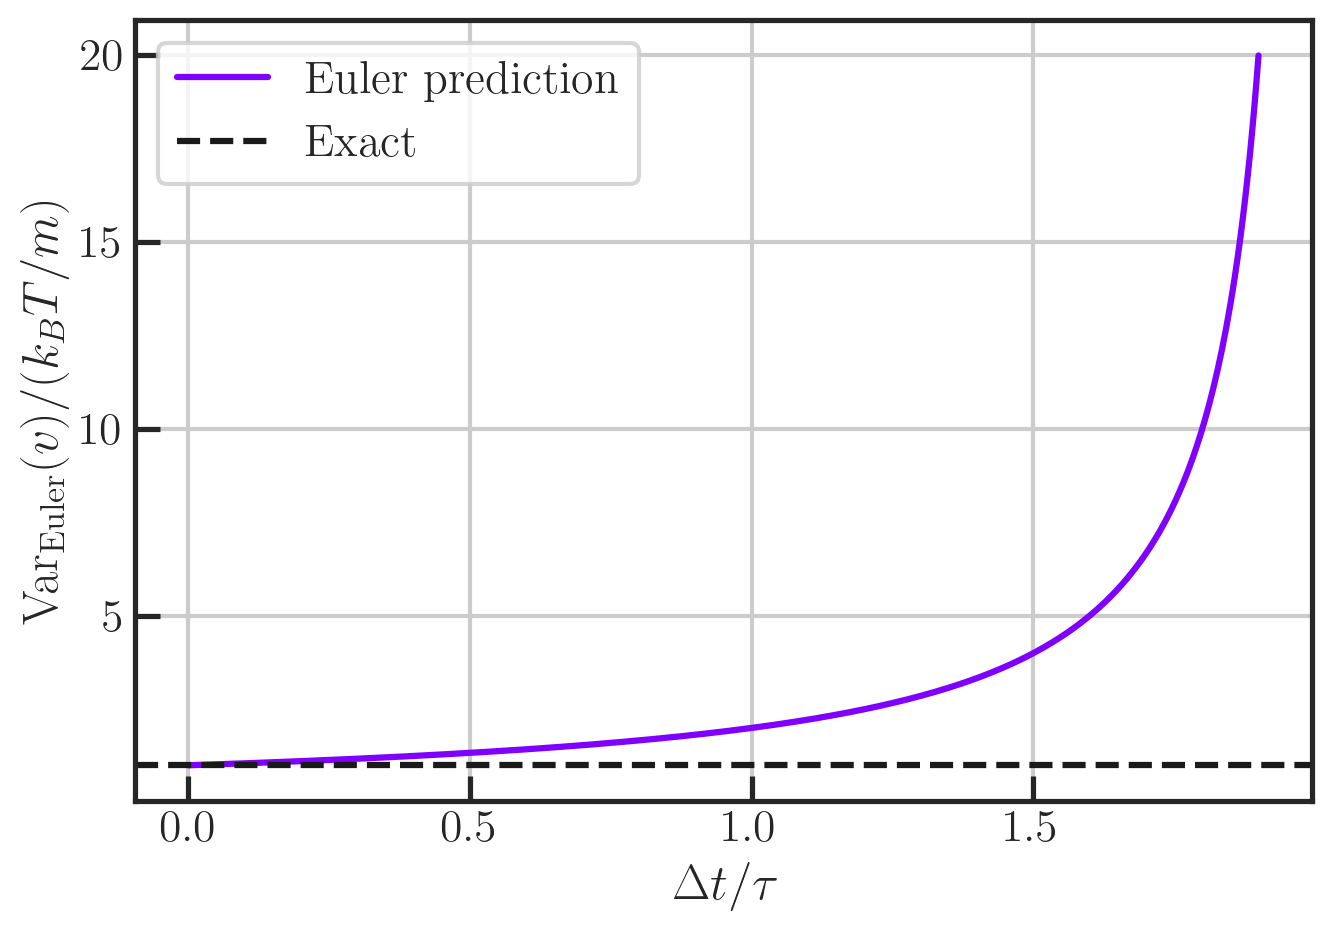

In [88]:
# ============================================================
# Euler bias in the stationary velocity variance
# ============================================================

dt_over_tau = np.linspace(0.001, 1.9, 500)

# Euler stationary variance:
# Var_Euler(v) = vT2 / (1 - dt/(2tau))
euler_stationary_var = 1 / (1 - dt_over_tau / 2)

plt.figure(figsize=(7, 5))
plt.plot(dt_over_tau, euler_stationary_var, label="Euler prediction")
plt.axhline(1, color="k", linestyle="--", label="Exact")


plt.xlabel(r"$\Delta t/\tau$")
plt.ylabel(r"$\mathrm{Var}_{\mathrm{Euler}}(v)/(k_BT/m)$")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

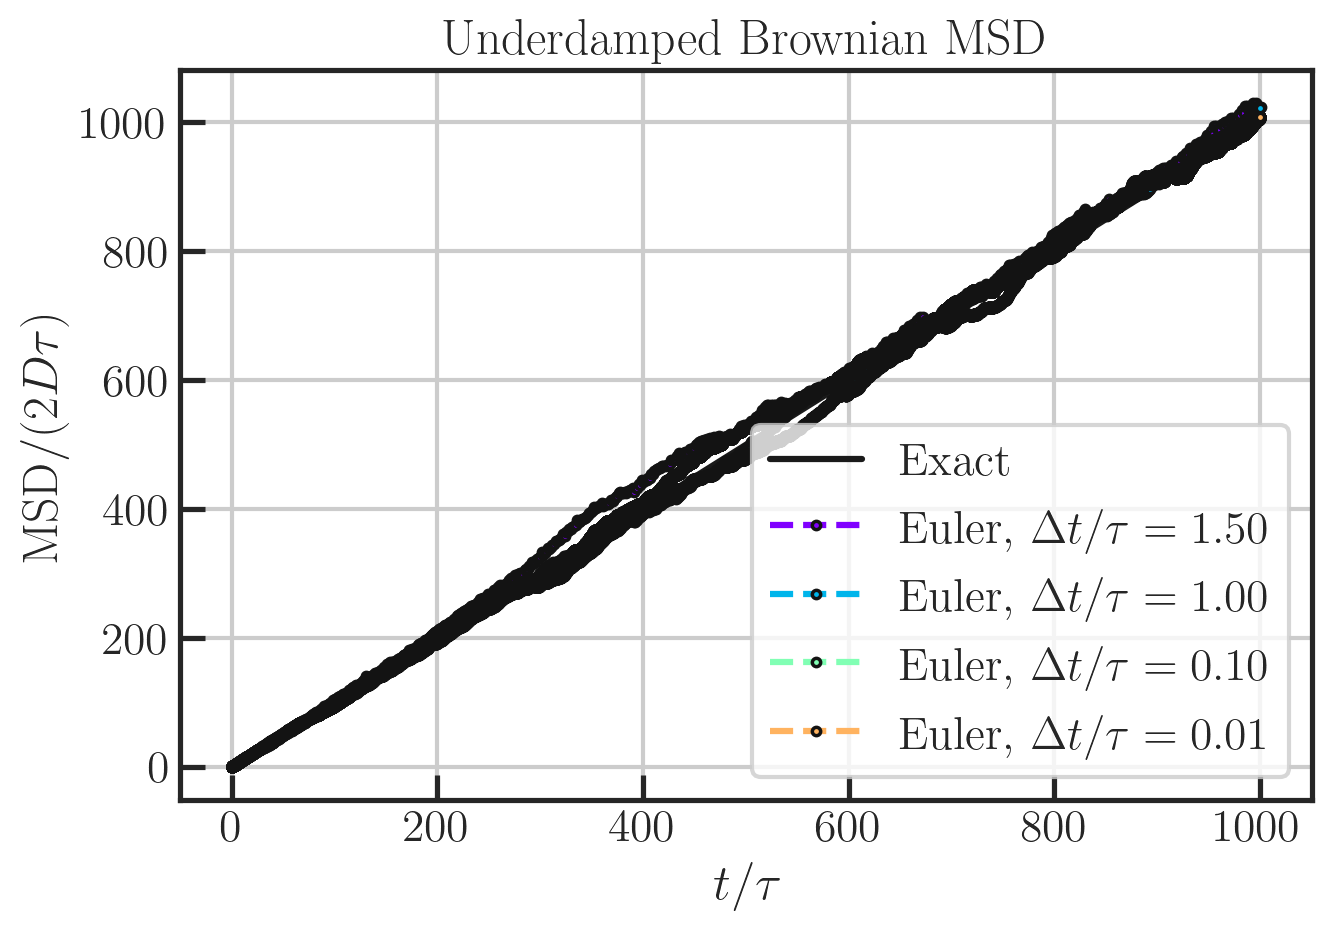

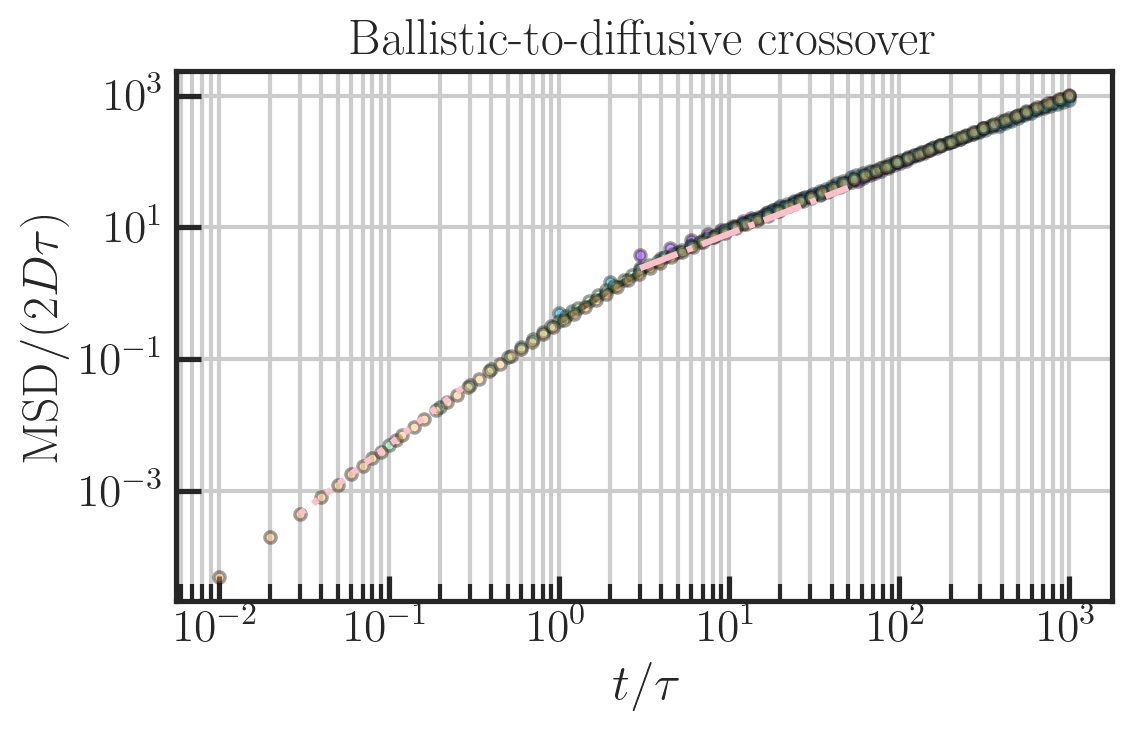

In [89]:
# ============================================================
# Plot 3: MSD from thermalized initial velocity
# ============================================================


def log_spaced_indices(t, n_points=40):
    positive = np.where(t > 0)[0]

    log_times = np.logspace(
        np.log10(t[positive[0]]), np.log10(t[positive[-1]]), n_points
    )
    indices = np.searchsorted(t, log_times)
    indices = np.unique(np.clip(indices, 0, len(t) - 1))

    return indices


plt.figure(figsize=(7, 5))

plt.plot(
    t_fine / tau,
    exact_msd_equilibrium_velocity(t_fine) / (2 * D * tau),
    "k",
    label="Exact",
)

for dt in dt_list:
    t, x, v = simulate_underdamped_euler(dt)

    dx = x - x[:, [0]]
    dx_centered = dx - np.mean(dx, axis=0)
    msd = np.mean(dx_centered**2, axis=0)

    plt.plot(
        t / tau,
        msd / (2 * D * tau),
        "o--",
        markersize=3,
        label=rf"Euler, $\Delta t/\tau={dt/tau:.2f}$",
    )

plt.xlabel(r"$t/\tau$")
plt.ylabel(r"$\mathrm{MSD}/(2D\tau)$")
plt.title("Underdamped Brownian MSD")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# Plot 4: MSD on log-log axes
# ============================================================

plt.figure(figsize=(6, 4))

plt.loglog(
    t_fine[1:] / tau,
    exact_msd_equilibrium_velocity(t_fine[1:]) / (2 * D * tau),
    "k",
    label="Exact",
)

for dt in dt_list:
    t, x, v = simulate_underdamped_euler(dt)

    dx = x - x[:, [0]]
    dx_centered = dx - np.mean(dx, axis=0)
    msd = np.mean(dx_centered**2, axis=0)

    idx = log_spaced_indices(t, n_points=80)

    plt.loglog(
        t[idx] / tau,
        msd[idx] / (2 * D * tau),
        "o",
        markersize=4,
        alpha=0.4,
        label=rf"Euler, $\Delta t/\tau={dt/tau:.2f}$",
    )

# guide slopes
tt = np.array([0.03, 0.3])
plt.loglog(tt, 0.5 * tt**2, ":", label=None, color="pink")
tt = np.array([3, 50])
plt.loglog(tt, 0.8 * tt, "-.", label=None, color="pink")

plt.xlabel(r"$t/\tau$")
plt.ylabel(r"$\mathrm{MSD}/(2D\tau)$")
plt.title("Ballistic-to-diffusive crossover")
# plt.legend()
plt.grid(True, which="both")
plt.tight_layout()
plt.show()

# 2D trajectory generation

In [90]:
def simulate_single_trajectory_2d(dt, tmax_traj):
    nsteps = int(np.round(tmax_traj / dt))
    t = np.arange(nsteps + 1) * dt

    x = np.zeros(nsteps + 1)
    y = np.zeros(nsteps + 1)
    vx = np.zeros(nsteps + 1)
    vy = np.zeros(nsteps + 1)

    vx[0] = rng.normal(0.0, vT)
    vy[0] = rng.normal(0.0, vT)

    noise_prefactor = np.sqrt(2 * vT2 * dt / tau)

    for n in range(nsteps):
        xi_x = rng.normal()
        xi_y = rng.normal()

        vx[n + 1] = vx[n] - (dt / tau) * vx[n] + noise_prefactor * xi_x
        vy[n + 1] = vy[n] - (dt / tau) * vy[n] + noise_prefactor * xi_y

        x[n + 1] = x[n] + dt * vx[n]
        y[n + 1] = y[n] + dt * vy[n]

    return t, x, y, vx, vy


dt_traj = 0.01 * tau

tmax_traj = 5000 * tau

t, x, y, vx, vy = simulate_single_trajectory_2d(dt=dt_traj, tmax_traj=tmax_traj)

# x(t) trajectory

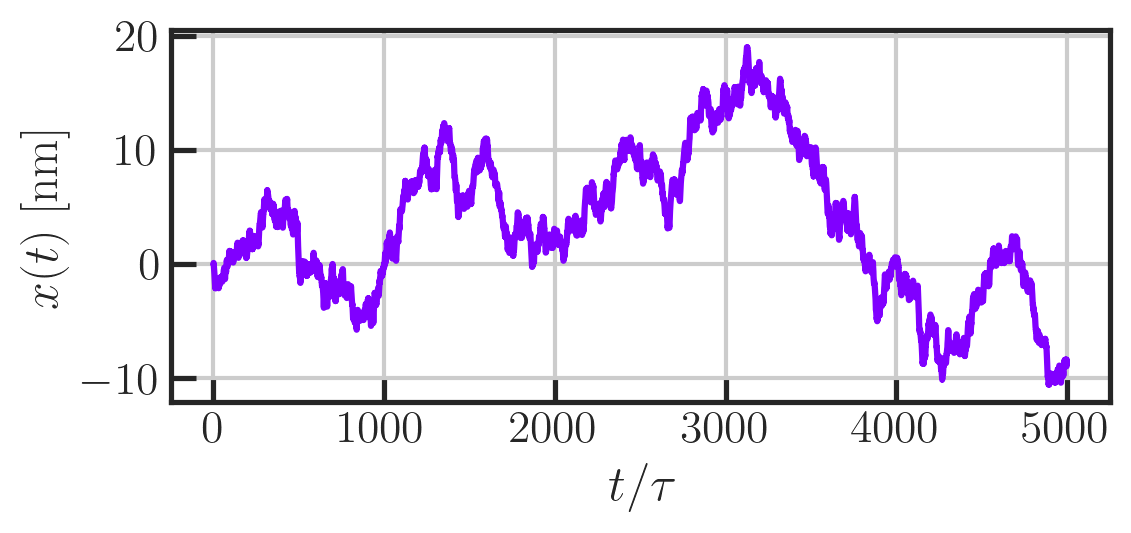

In [91]:
plt.figure(figsize=(6, 3))

plt.plot(t / tau, x * 1e9)

plt.xlabel(r"$t/\tau$")
plt.ylabel(r"$x(t)$ [nm]")
plt.grid(True)
plt.tight_layout()
plt.show()

# A nicer rainbow 2D trajectory

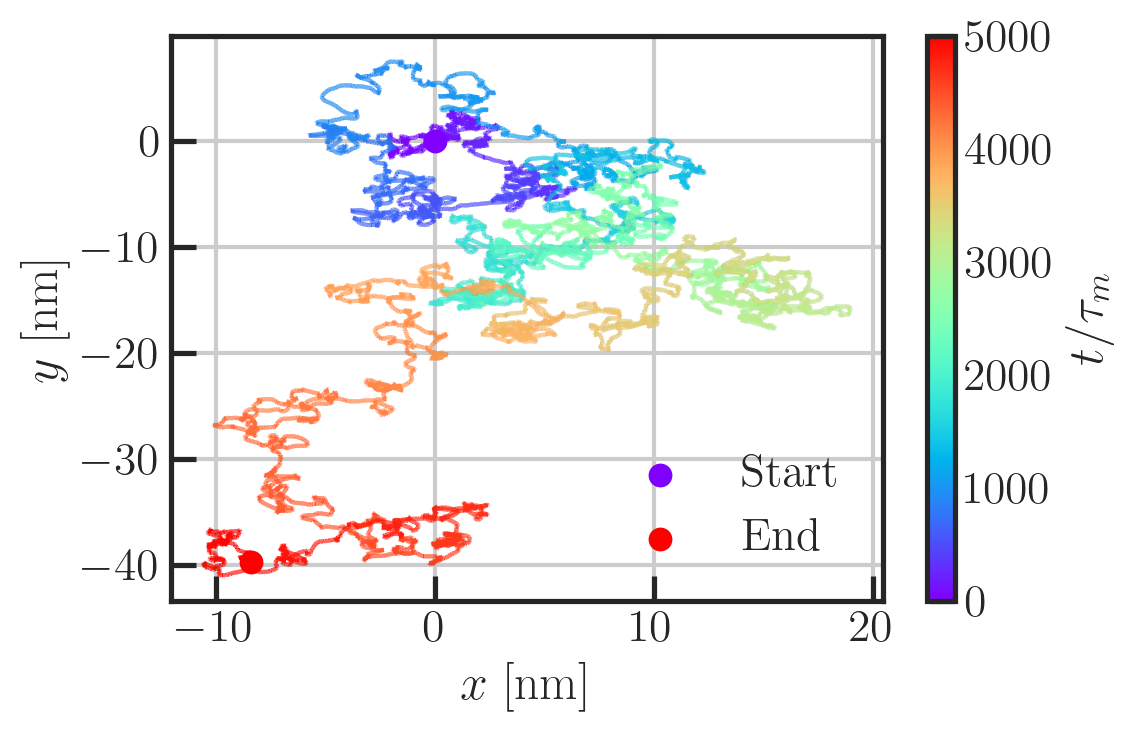

In [93]:
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

fig, ax = plt.subplots(figsize=(6, 4))

# to nm
x_nm = x * 1e9
y_nm = y * 1e9

points = np.array([x_nm, y_nm]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=t[0] / tau, vmax=t[-1] / tau)

lc = LineCollection(segments, cmap="rainbow", norm=norm, linewidth=1.5)

lc.set_array(t[:-1] / tau)

line = ax.add_collection(lc)

ax.scatter(x_nm[0], y_nm[0], s=50, label="Start", zorder=3, color="C0")
ax.scatter(x_nm[-1], y_nm[-1], s=50, label="End", zorder=3, color="C19")

cbar = fig.colorbar(line, ax=ax)
cbar.set_label(r"$t/\tau_m$")

ax.set_xlabel(r"$x$ [nm]")
ax.set_ylabel(r"$y$ [nm]")
ax.legend(frameon=False, loc="lower right")
ax.grid(True)

plt.tight_layout()
plt.savefig("2dbrown_traj.pdf", transparent=True)
plt.show()